In [9]:
import json
import matplotlib.pyplot as plt
import pandas as pd

from collections import defaultdict

In [4]:
folder = "ablate_by_difficulty_500_es"
pft_suffix = ""
epochs = 200
num_samples = 500

/tmp/ipykernel_1494751/3744791040.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_records.groupby("x").apply(lambda df: list(df["y"])).to_dict()
/tmp/ipykernel_1494751/3744791040.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[row_idx, col_idx].legend(loc="lower center", ncol=4)
/tmp/ipykernel_1494751/3744791040.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the grou

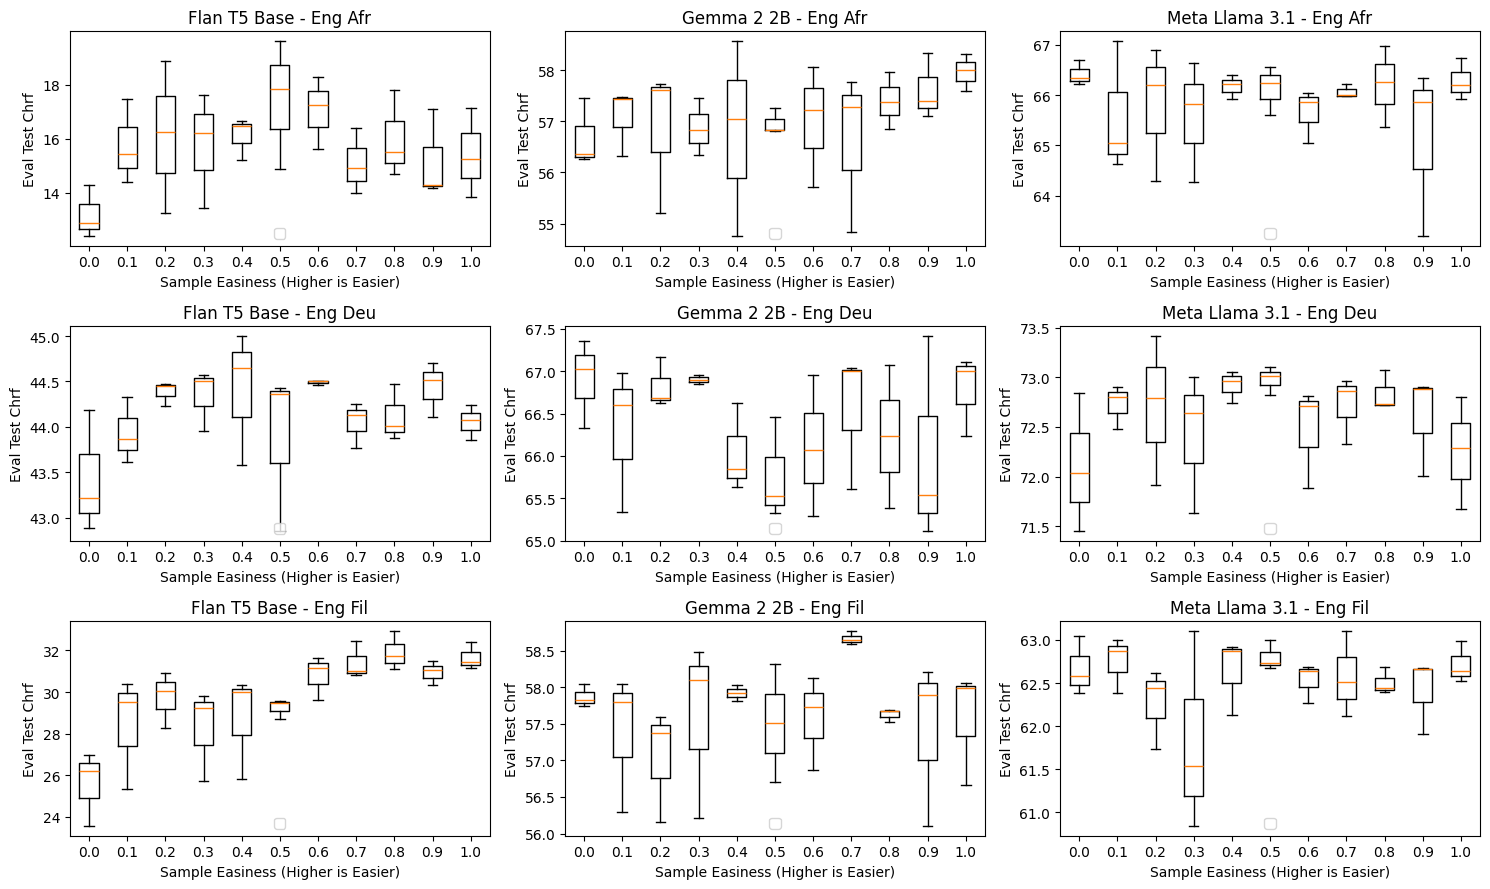

In [20]:
dataset_metric_pairs = [
    ("eng_afr", "eval_test_chrf"),
    ("eng_deu", "eval_test_chrf"),
    ("eng_fil", "eval_test_chrf"),
    # ("squad", "eval_f1"),
    # ("hotpotqa", "eval_f1"),
    # ("gsm8k", "eval_exact_match_gsm8k"),
    # ("math", "eval_exact_match_math"),
]

fig, ax = plt.subplots(3, 3, figsize=(15, 9))

for row_idx, (dataset, eval_metric) in enumerate(dataset_metric_pairs):
    for col_idx, model in enumerate(
        ["flan-t5-base", "gemma-2-2b-it-bnb-4bit", "Meta-Llama-3.1-8B"]
    ):

        records = list[tuple([float, float])]()
        for seed in [16, 27, 38]:
            results = json.load(
                open(
                    f"results/{folder}/{dataset}_eps_{epochs}_{model}_ft_{num_samples}_seed_{seed}{pft_suffix}_ablation.json"
                )
            )
            xs = [float(x) for x in results.keys()]
            ys = [float(results[k][eval_metric]) for k in results.keys()]
            records.extend([(x, y) for (x, y) in zip(xs, ys)])
        df_records = pd.DataFrame.from_records(records, columns=["x", "y"])

        title = f"{' '.join(model.split("-")[:3]).title()} - {dataset.replace('_', ' ').title()}"
        x_label = (
            "Sample Easiness (Higher is Easier)"
            if "by_difficulty" in folder
            else "Sample Confidence (Higher is More Confident)"
        )
        y_label = eval_metric.replace("_", " ").title()

        grouped_eval_scores = (
            df_records.groupby("x").apply(lambda df: list(df["y"])).to_dict()
        )

        ax[row_idx, col_idx].boxplot(
            [grouped_eval_scores[key] for key in grouped_eval_scores.keys()],
            orientation="vertical",
            tick_labels=[round(key, 1) for key in grouped_eval_scores.keys()],
        )
        ax[row_idx, col_idx].set_title(title)
        ax[row_idx, col_idx].set_xlabel(x_label)
        ax[row_idx, col_idx].set_ylabel(y_label)
        ax[row_idx, col_idx].legend(loc="lower center", ncol=4)

    # # Add random sampling
    # try:
    #     results = json.load(
    #         open(
    #             f"results/ablate_random/{dataset}_eps_{epochs}_{model}_seed_{seed}_random_ablation.json"
    #         )
    #     )
    #     y = results["random"][eval_metric]
    #     plot_on_fig(
    #         None,
    #         y,
    #         row_idx,
    #         col_idx,
    #         plot_title=title,
    #         line_label="Rdm",
    #         y_label=eval_metric,
    #     )
    # except FileNotFoundError:
    #     continue
fig.tight_layout()